# Empirical Characterization of the CDS - Oil relationship

## Loading data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import datetime


In [2]:
# Read CDS sheet from masterfile
#CDS_df = pd.read_excel('data/raw/data_masterfile.xlsx', sheet_name='CDS')
#CDS_df = CDS_df.rename(columns={'Dates': 'Date'})
#CDS_df['Date'] = pd.to_datetime(CDS_df['Date'])
#CDS_df.set_index('Date', inplace=True)
#CDS_df.columns = [col.replace('_USD', '') for col in CDS_df.columns]

CDS_df = pd.read_csv('data/processed/CDS/Weekly_CDS.csv')
CDS_df['Date'] = pd.to_datetime(CDS_df['Date'])
CDS_df.set_index('Date', inplace=True)

# Read Oil data from csv
Oil_df = pd.read_csv('data/raw/brent_ovx_weekly.csv')
Oil_df['Date'] = pd.to_datetime(Oil_df['Date'])
Oil_df.set_index('Date', inplace=True)

# Merge datasets
merged = pd.merge(CDS_df, Oil_df, on='Date', how='inner')
merged.head()


,United States,United Kingdom,Japan,Australia,China,France,Germany,India,Italy,Turkey,...,Norway,Denmark,Cyprus,Iceland,United Arab Emirates,Taiwan,Abu Dhabi,Dubai,Brent,OVX
Date,,,,,,,,,,,,,,,,,,,,,
2008-01-04,NaN,NaN,NaN,NaN,29.2365,NaN,6.275,NaN,NaN,186.93,...,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN,96.790001,34.500000
2008-01-11,NaN,NaN,NaN,NaN,29.2365,NaN,8.250,NaN,NaN,188.36,...,NaN,NaN,15.0,NaN,NaN,NaN,NaN,NaN,91.070000,32.119999
2008-01-18,NaN,NaN,NaN,NaN,29.2365,NaN,8.250,NaN,NaN,188.36,...,NaN,NaN,17.0,NaN,NaN,NaN,NaN,NaN,89.230003,31.459999
2008-01-25,NaN,NaN,NaN,NaN,29.2365,NaN,7.250,NaN,NaN,188.36,...,NaN,NaN,18.0,NaN,NaN,NaN,NaN,NaN,90.900002,31.959999
2008-02-01,NaN,NaN,NaN,NaN,29.2365,NaN,6.500,NaN,NaN,188.36,...,NaN,NaN,19.0,NaN,NaN,NaN,NaN,NaN,89.440002,29.770000


/var/folders/wy/gjw_3_n51t748hfngpz4zf0w0000gn/T/ipykernel_25903/1498499610.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


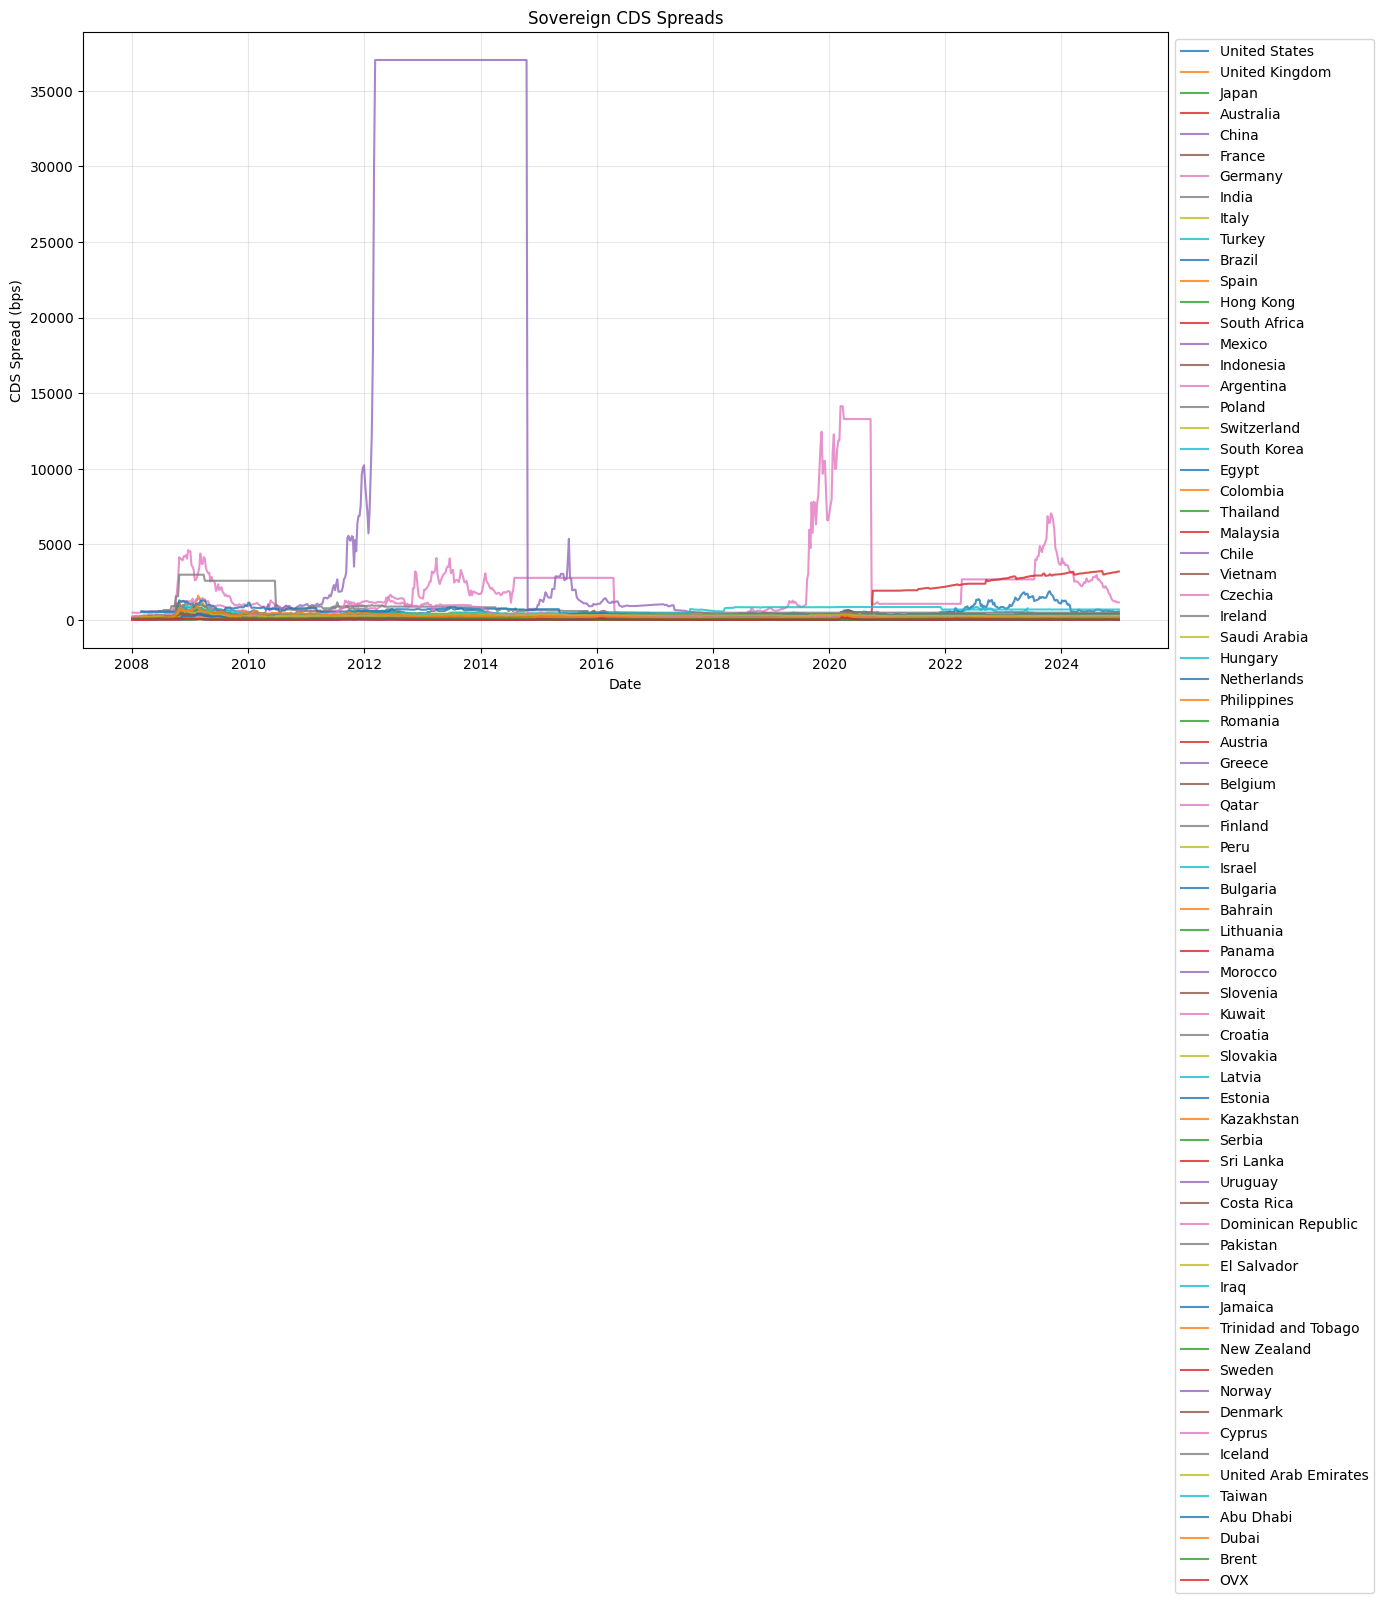

In [3]:
# Plot all CDS spreads
fig, ax = plt.subplots(figsize=(14, 8))

for col in merged.columns:
    ax.plot(merged.index, merged[col], label=col, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('CDS Spread (bps)')
ax.set_title('Sovereign CDS Spreads')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
oil_exporters = ['Saudi Arabia', 'Abu Dhabi','Dubai','Qatar','Colombia','Mexico','Brazil','Egypt','Malaysia']
controls = ['Indonesia','Philippines','Turkey','Chile','China','South Africa','South Korea','Thailand'] 
# Filter to 2018+ and selected countries
final_df = merged[merged.index >= datetime.datetime(2014,1,1)][['Brent', 'OVX'] + oil_exporters + controls].copy()

print(f"Final sample: {final_df.shape}")
final_df.to_csv('final_sample.csv', index=True)

Final sample: (574, 19)


### Correlation between Oil Volatility and CDS returns

In [5]:
# Compute returns
final_df['oil_ret'] = final_df['OVX'].pct_change()

oil_down = final_df[final_df['oil_ret'] > 0]


# Correlations
print("=== OIL-CDS CORRELATIONS ===\n")
print("Oil Exporters:")
for country in oil_exporters:
    if country in final_df.columns:
        cds_ret = final_df[country].pct_change()
        corr = oil_down['oil_ret'].corr(oil_down[country].pct_change())
        print(f"  {country}: {corr:+.3f}")

print("\nControl Group:")
for country in controls:
    if country in final_df.columns:
        cds_ret = final_df[country].pct_change()
        corr = oil_down['oil_ret'].corr(oil_down[country].pct_change())
        print(f"  {country}: {corr:+.3f}")

=== OIL-CDS CORRELATIONS ===

Oil Exporters:
  Saudi Arabia: +0.248
  Abu Dhabi: +0.331
  Dubai: +0.368
  Qatar: +0.329
  Colombia: +0.388
  Mexico: +0.390
  Brazil: +0.379
  Egypt: +0.307
  Malaysia: +0.315

Control Group:
  Indonesia: +0.353
  Philippines: +0.299
  Turkey: +0.250
  Chile: +0.292
  China: +0.155
  South Africa: +0.362
  South Korea: +0.157
  Thailand: +0.285


## Jump detection

In [6]:
# 1. JUMP DETECTION
print("=== JUMP DETECTION ===\n")

jump_threshold = 2 #

def count_jumps(series, threshold=3):
    returns = series.pct_change().dropna()
    std = returns.std()
    jumps = (returns.abs() > threshold * std).sum()
    pct = jumps / len(returns) * 100
    return jumps, pct, len(returns)

print("Oil:")
j, p, n = count_jumps(final_df['Brent'],jump_threshold)
print(f"  Jumps: {j} ({p:.2f}%) out of {n} obs")

print("\nCDS:")
for country in oil_exporters:
    if country in final_df.columns:
        j, p, n = count_jumps(merged[country], jump_threshold)
        print(f"  {country}: {j} jumps ({p:.2f}%)")

=== JUMP DETECTION ===

Oil:
  Jumps: 25 (4.36%) out of 573 obs

CDS:
  Saudi Arabia: 26 jumps (3.47%)
  Abu Dhabi: 35 jumps (4.01%)
  Dubai: 29 jumps (3.30%)
  Qatar: 37 jumps (4.18%)
  Colombia: 28 jumps (3.16%)
  Mexico: 26 jumps (2.93%)
  Brazil: 35 jumps (3.95%)
  Egypt: 36 jumps (4.26%)
  Malaysia: 28 jumps (3.16%)


## Co-Jump

In [7]:
# 2. CO-JUMPS
print("\n=== CO-JUMP ANALYSIS ===\n")

oil_ret = merged['Brent'].pct_change()
oil_std = oil_ret.std()
oil_jumps = oil_ret.abs() > 2 * oil_std

print(f"Oil jump days: {oil_jumps.sum()}\n")

for group in [oil_exporters, controls]:

    if group is oil_exporters:
        print("Oil Exporters \n")
    elif group is controls:
        print("\nControls\n")

    for country in group:
        if country in merged.columns:
            cds_ret = merged[country].pct_change()
            cds_std = cds_ret.std()
            cds_jumps = cds_ret.abs() > 2 * cds_std
            
            # Co-jumps
            co_jumps = (oil_jumps & cds_jumps).sum()
            
            # Conditional probability
            p_cds_given_oil = co_jumps / oil_jumps.sum() if oil_jumps.sum() > 0 else 0
            p_cds_unconditional = cds_jumps.sum() / len(cds_jumps)
            
            ratio = p_cds_given_oil / p_cds_unconditional if p_cds_unconditional > 0 else 0
            
            print(f"{country}: P(CDS jump | oil jump) = {p_cds_given_oil:.1%}, unconditional = {p_cds_unconditional:.1%}, ratio = {ratio:.1f}x")


=== CO-JUMP ANALYSIS ===

Oil jump days: 39

Oil Exporters 

Saudi Arabia: P(CDS jump | oil jump) = 12.8%, unconditional = 2.9%, ratio = 4.4x
Abu Dhabi: P(CDS jump | oil jump) = 17.9%, unconditional = 3.9%, ratio = 4.5x
Dubai: P(CDS jump | oil jump) = 15.4%, unconditional = 3.3%, ratio = 4.7x
Qatar: P(CDS jump | oil jump) = 20.5%, unconditional = 4.2%, ratio = 4.9x
Colombia: P(CDS jump | oil jump) = 23.1%, unconditional = 3.2%, ratio = 7.3x
Mexico: P(CDS jump | oil jump) = 28.2%, unconditional = 2.9%, ratio = 9.6x
Brazil: P(CDS jump | oil jump) = 30.8%, unconditional = 3.9%, ratio = 7.8x
Egypt: P(CDS jump | oil jump) = 15.4%, unconditional = 4.1%, ratio = 3.8x
Malaysia: P(CDS jump | oil jump) = 12.8%, unconditional = 3.2%, ratio = 4.1x

Controls

Indonesia: P(CDS jump | oil jump) = 20.5%, unconditional = 3.9%, ratio = 5.2x
Philippines: P(CDS jump | oil jump) = 20.5%, unconditional = 3.9%, ratio = 5.2x
Turkey: P(CDS jump | oil jump) = 25.6%, unconditional = 4.5%, ratio = 5.7x
Chile: P(

In [8]:
# 3. ASYMMETRY TEST
print("\n=== ASYMMETRY TEST ===\n")

import statsmodels.api as sm

oil_ret = merged['Brent'].pct_change()
oil_neg = oil_ret.clip(upper=0)  # Only negative returns
oil_pos = oil_ret.clip(lower=0)  # Only positive returns

for group in [oil_exporters, controls]:

    if group is oil_exporters:
        print("Oil Exporters \n")
    elif group is controls:
        print("\nControls\n")

    for country in group:
        if country in merged.columns:
            cds_ret = merged[country].pct_change()
            
            # Align
            data = pd.DataFrame({
                'cds': cds_ret,
                'oil_neg': oil_neg,
                'oil_pos': oil_pos
            }).dropna()
            
            X = sm.add_constant(data[['oil_neg', 'oil_pos']])
            model = sm.OLS(data['cds'], X).fit()
            
            print(f"{country}:")
            print(f"  β_neg = {model.params['oil_neg']:.3f} (oil crashes)")
            print(f"  β_pos = {model.params['oil_pos']:.3f} (oil rallies)")
            print(f"  Asymmetry: {abs(model.params['oil_neg']) - abs(model.params['oil_pos']):.3f}")



=== ASYMMETRY TEST ===

Oil Exporters 

Saudi Arabia:
  β_neg = -0.591 (oil crashes)
  β_pos = -0.084 (oil rallies)
  Asymmetry: 0.507
Abu Dhabi:
  β_neg = -0.614 (oil crashes)
  β_pos = -0.039 (oil rallies)
  Asymmetry: 0.575
Dubai:
  β_neg = -0.770 (oil crashes)
  β_pos = -0.003 (oil rallies)
  Asymmetry: 0.767
Qatar:
  β_neg = -0.792 (oil crashes)
  β_pos = 0.037 (oil rallies)
  Asymmetry: 0.755
Colombia:
  β_neg = -1.303 (oil crashes)
  β_pos = -0.139 (oil rallies)
  Asymmetry: 1.164
Mexico:
  β_neg = -1.338 (oil crashes)
  β_pos = -0.168 (oil rallies)
  Asymmetry: 1.170
Brazil:
  β_neg = -1.104 (oil crashes)
  β_pos = -0.027 (oil rallies)
  Asymmetry: 1.077
Egypt:
  β_neg = -0.490 (oil crashes)
  β_pos = 0.149 (oil rallies)
  Asymmetry: 0.341
Malaysia:
  β_neg = -1.110 (oil crashes)
  β_pos = -0.082 (oil rallies)
  Asymmetry: 1.028

Controls

Indonesia:
  β_neg = -1.053 (oil crashes)
  β_pos = -0.008 (oil rallies)
  Asymmetry: 1.045
Philippines:
  β_neg = -0.928 (oil crashes)
  β

In [9]:
# 4. TAIL DEPENDENCE
print("\n=== TAIL DEPENDENCE ===\n")

oil_ret = merged['Brent'].pct_change()

# Bottom 10% of oil returns (crashes)
threshold = oil_ret.quantile(0.05)
crash_days = oil_ret < threshold

print(f"Oil crash days (bottom 10%): {crash_days.sum()}\n")

print("Correlation during oil crashes vs. normal:")
for group in [oil_exporters, controls]:

    if group is oil_exporters:
        print("Oil Exporters \n")
    elif group is controls:
        print("\nControls\n")

    for country in group:
        if country in merged.columns:
            cds_ret = merged[country].pct_change()
            
            corr_crash = oil_ret[crash_days].corr(cds_ret[crash_days])
            corr_normal = oil_ret[~crash_days].corr(cds_ret[~crash_days])
            
            print(f"  {country}: crash = {corr_crash:+.3f}, normal = {corr_normal:+.3f}, diff = {corr_crash - corr_normal:+.3f}")


=== TAIL DEPENDENCE ===

Oil crash days (bottom 10%): 45

Correlation during oil crashes vs. normal:
Oil Exporters 

  Saudi Arabia: crash = -0.528, normal = -0.106, diff = -0.421
  Abu Dhabi: crash = -0.380, normal = -0.092, diff = -0.288
  Dubai: crash = -0.464, normal = -0.097, diff = -0.366
  Qatar: crash = -0.451, normal = -0.095, diff = -0.356
  Colombia: crash = -0.426, normal = -0.222, diff = -0.204
  Mexico: crash = -0.419, normal = -0.212, diff = -0.207
  Brazil: crash = -0.493, normal = -0.149, diff = -0.344
  Egypt: crash = -0.300, normal = -0.021, diff = -0.280
  Malaysia: crash = -0.393, normal = -0.156, diff = -0.238

Controls

  Indonesia: crash = -0.431, normal = -0.143, diff = -0.288
  Philippines: crash = -0.386, normal = -0.149, diff = -0.237
  Turkey: crash = -0.248, normal = -0.096, diff = -0.152
  Chile: crash = -0.346, normal = -0.171, diff = -0.175
  China: crash = -0.298, normal = -0.123, diff = -0.175
  South Africa: crash = -0.134, normal = -0.176, diff = +